<a href="https://colab.research.google.com/github/sushantprakash098/Electricity-Demand-Forecasting-App/blob/main/Electricity_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# import pandas as pd
# !ls /content/drive/MyDrive/Electricity_Demand_Project/Data/PJME_hourly.csv
df = pd.read_csv('/content/drive/MyDrive/Electricity_Demand_Project/Data/PJME_hourly.csv')

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [4]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


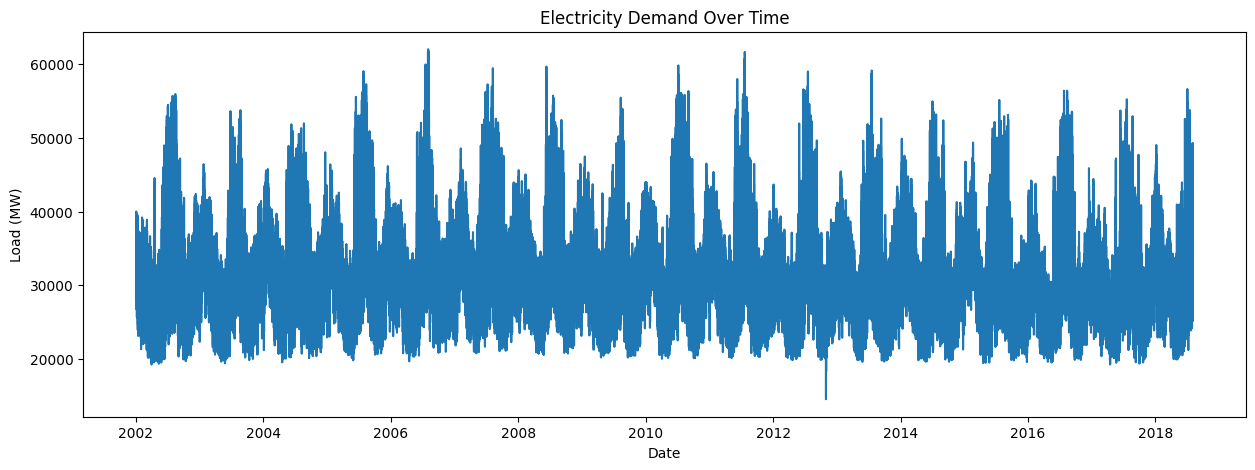

In [5]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['PJME_MW'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.show()

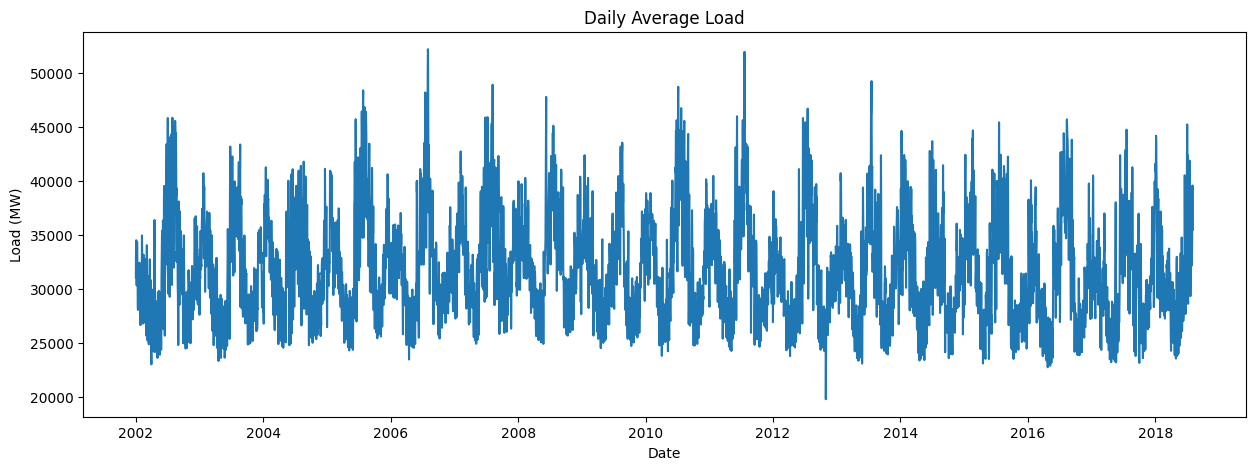

In [6]:
daily_avg = df.resample('D').mean()

plt.figure(figsize=(15,5))
plt.plot(daily_avg.index, daily_avg['PJME_MW'])
plt.title("Daily Average Load")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.show()

In [7]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,month,year
Datetime,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002
2002-01-01 02:00:00,29265.0,2,1,1,2002
2002-01-01 03:00:00,28357.0,3,1,1,2002
2002-01-01 04:00:00,27899.0,4,1,1,2002
2002-01-01 05:00:00,28057.0,5,1,1,2002


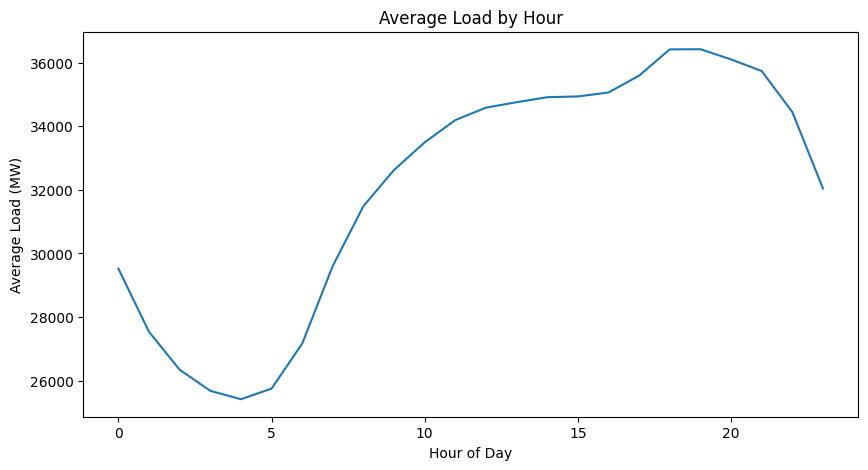

In [8]:
hourly_avg = df.groupby('hour')['PJME_MW'].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Load by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.show()

In [9]:
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

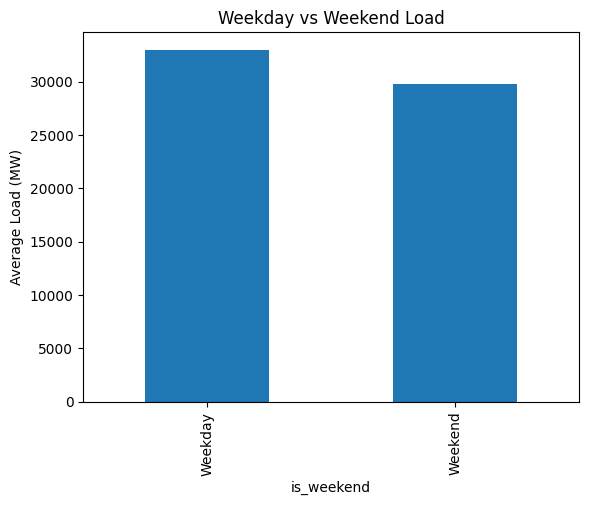

In [10]:
weekend_avg = df.groupby('is_weekend')['PJME_MW'].mean()

weekend_avg.plot(kind='bar')
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.title("Weekday vs Weekend Load")
plt.ylabel("Average Load (MW)")
plt.show()

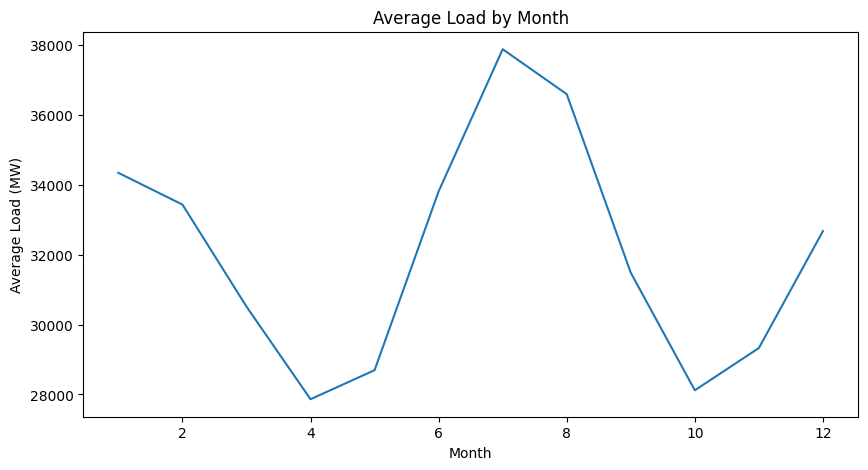

In [11]:
monthly_avg = df.groupby('month')['PJME_MW'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot()
plt.title("Average Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Load (MW)")
plt.show()

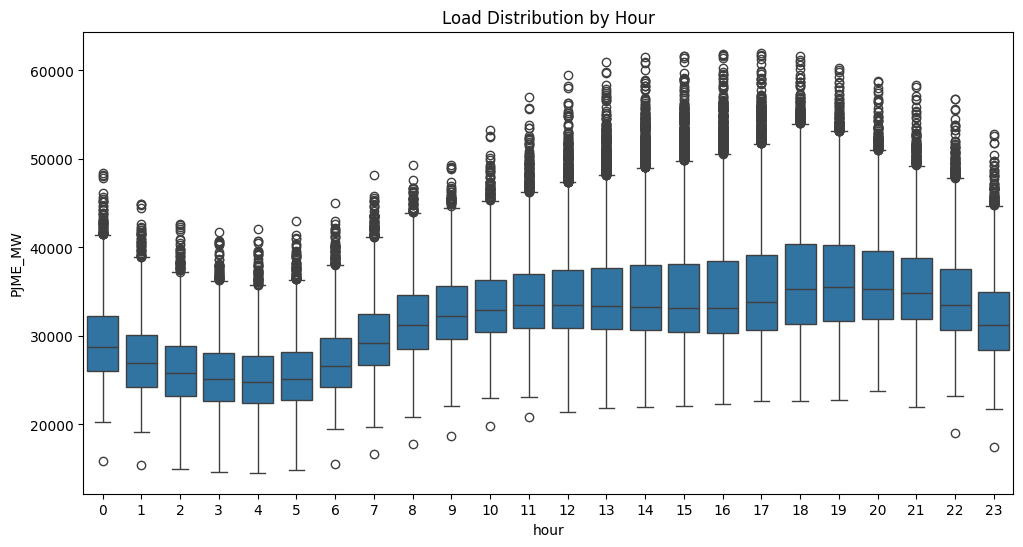

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x=df['hour'], y=df['PJME_MW'])
plt.title("Load Distribution by Hour")
plt.show()

In [13]:
df['lag_1'] = df['PJME_MW'].shift(1)

In [14]:
df['lag_24'] = df['PJME_MW'].shift(24)

In [15]:
df['lag_168'] = df['PJME_MW'].shift(168)

In [16]:
df['rolling_mean_24'] = df['PJME_MW'].rolling(window=24).mean()

In [17]:
df.head(30)

,PJME_MW,hour,dayofweek,month,year,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24
Datetime,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002,0,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,2002,0,30393.0,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,2002,0,29265.0,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,2002,0,28357.0,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,2002,0,27899.0,NaN,NaN,NaN
2002-01-01 06:00:00,28654.0,6,1,1,2002,0,28057.0,NaN,NaN,NaN
2002-01-01 07:00:00,29308.0,7,1,1,2002,0,28654.0,NaN,NaN,NaN
2002-01-01 08:00:00,29595.0,8,1,1,2002,0,29308.0,NaN,NaN,NaN
2002-01-01 09:00:00,29943.0,9,1,1,2002,0,29595.0,NaN,NaN,NaN


In [18]:
df = df.dropna()
features = [
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24'
]

X = df[features]
y = df['PJME_MW']
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]
print(X_train.shape)
print(X_test.shape)

(116158, 8)
(29040, 8)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mape = np.mean(np.abs((y_test - lr_pred) / y_test)) * 100

print("Linear Regression Performance:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("MAPE:", lr_mape)

Linear Regression Performance:
MAE: 976.6933699714795
RMSE: 1253.5830300590437
MAPE: 3.146544920582997


In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print("Random Forest Performance:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape)
print("Model Comparison")
print("----------------------------")
print(f"Linear Regression RMSE: {lr_rmse}")
print(f"Random Forest RMSE: {rf_rmse}")

Random Forest Performance:
MAE: 322.4943109504132
RMSE: 443.6905664242214
MAPE: 1.0250688323602068
Model Comparison
----------------------------
Linear Regression RMSE: 1253.5830300590437
Random Forest RMSE: 443.6905664242214


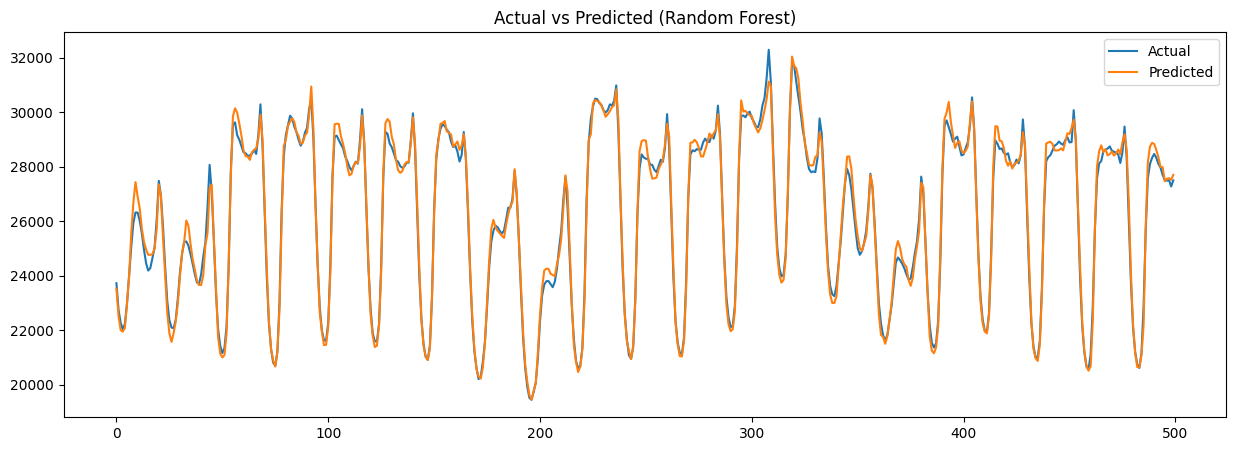

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(rf_pred[:500], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

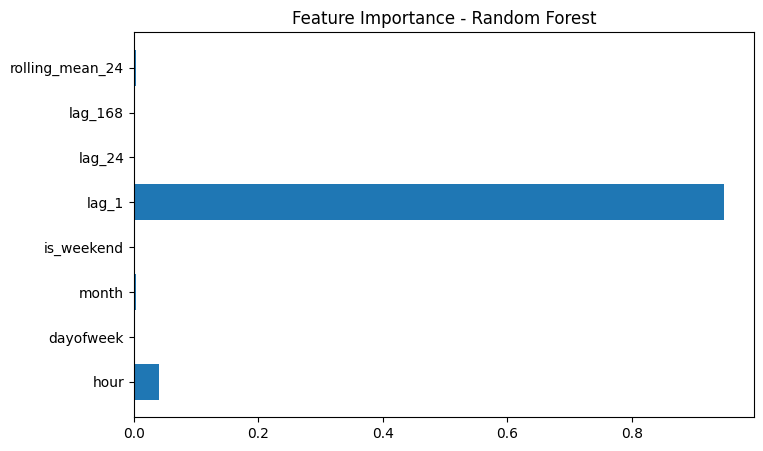

In [23]:
importance = rf_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance - Random Forest")
plt.show()

In [24]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [25]:
data = df[['PJME_MW']].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
def create_sequences(data, window_size=24):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

window_size = 24
X_lstm, y_lstm = create_sequences(data_scaled, window_size)
train_size = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:train_size]
X_test_lstm = X_lstm[train_size:]

y_train_lstm = y_lstm[:train_size]
y_test_lstm = y_lstm[train_size:]
print(X_train_lstm.shape)

(116139, 24, 1)


In [26]:
model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)
lstm_pred = model.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test_lstm)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - loss: 0.0066 - val_loss: 3.4625e-04
Epoch 2/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 2.6082e-04 - val_loss: 1.1990e-04
Epoch 3/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.7202e-04 - val_loss: 9.7407e-05
Epoch 4/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.4117e-04 - val_loss: 8.7713e-05
Epoch 5/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.2735e-04 - val_loss: 8.4938e-05
Epoch 6/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.2558e-04 - val_loss: 1.1398e-04
Epoch 7/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 1.1271e-04 - val_loss: 6.8757e-05
Epoch 8/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 9.8871e-05 - val_loss: 7.8095e-05
Epoch 9/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 8.7303e-05 - val_loss: 6.0774e-05
Epoch 10/10
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 7.7099e-05 - val_loss: 5.3444e-05
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 253.2524974572714
LSTM RMSE: 346.99576092405914


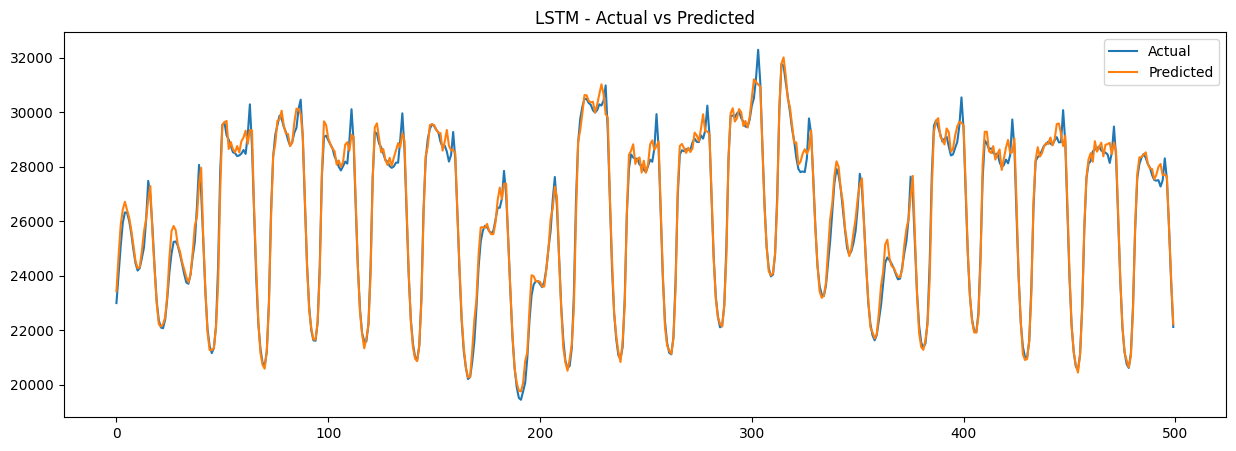

In [28]:
plt.figure(figsize=(15,5))
plt.plot(y_test_actual[:500], label="Actual")
plt.plot(lstm_pred[:500], label="Predicted")
plt.legend()
plt.title("LSTM - Actual vs Predicted")
plt.show()

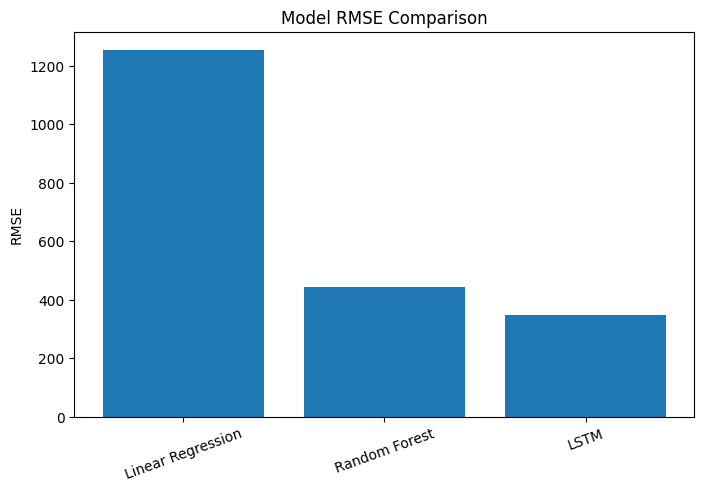

In [29]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "LSTM"],
    "MAE": [lr_mae, rf_mae, lstm_mae],
    "RMSE": [lr_rmse, rf_rmse, lstm_rmse]
})

results
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()


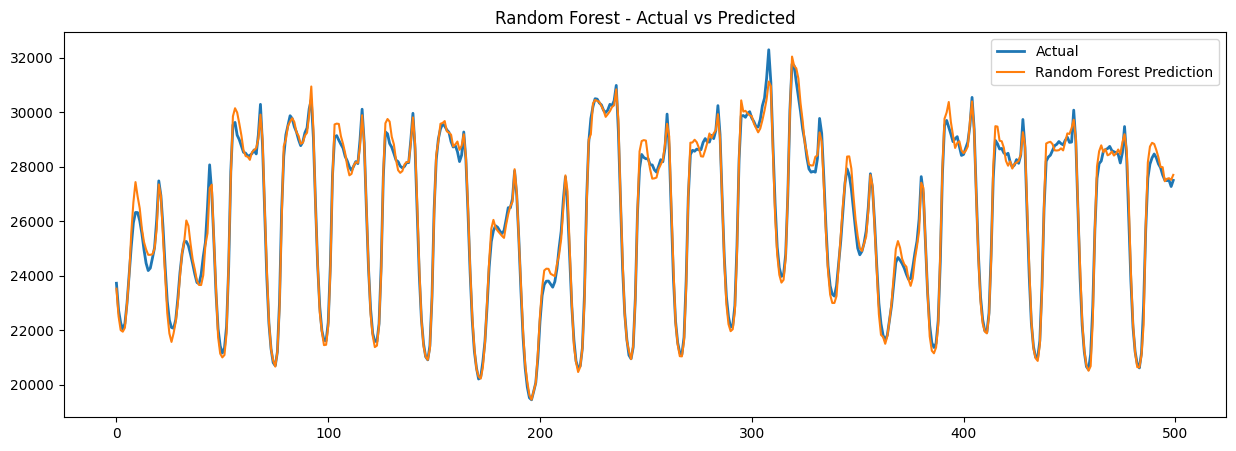

In [30]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:500], label="Actual", linewidth=2)
plt.plot(rf_pred[:500], label="Random Forest Prediction")
plt.legend()
plt.title("Random Forest - Actual vs Predicted")
plt.show()


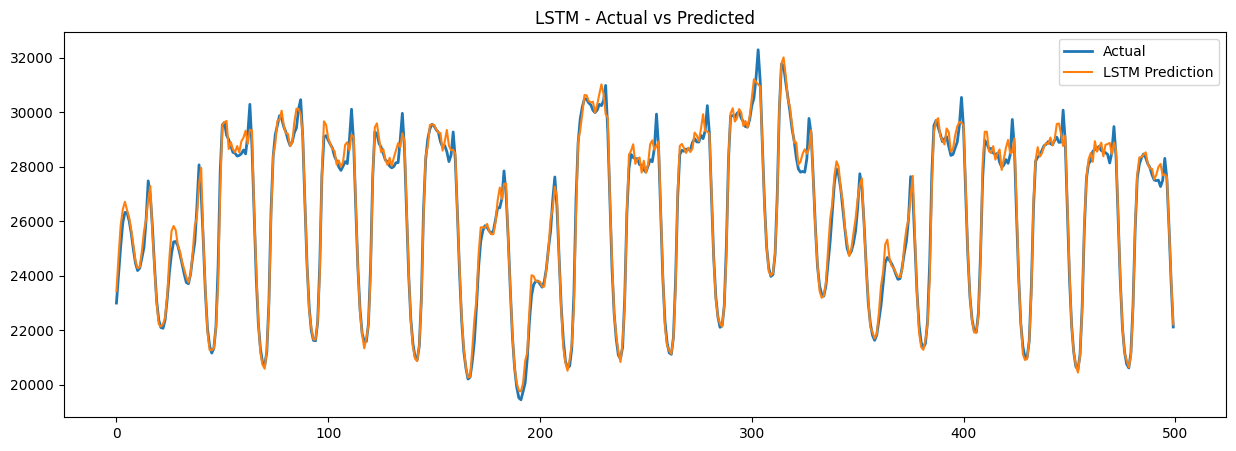

In [31]:
plt.figure(figsize=(15,5))
plt.plot(y_test_actual[:500], label="Actual", linewidth=2)
plt.plot(lstm_pred[:500], label="LSTM Prediction")
plt.legend()
plt.title("LSTM - Actual vs Predicted")
plt.show()

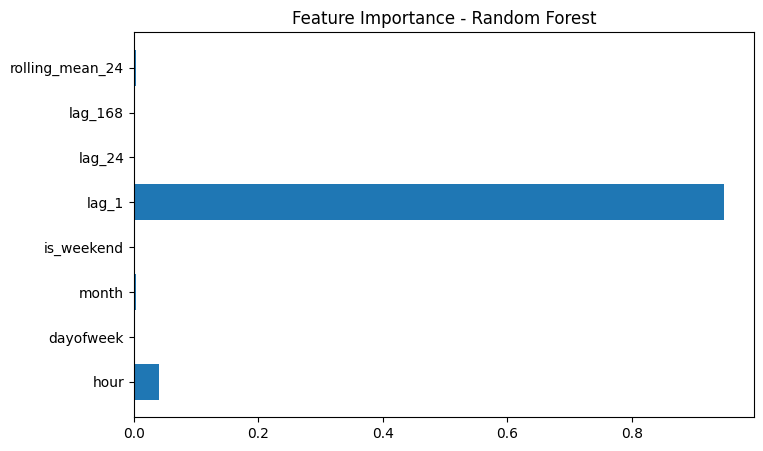

In [32]:
importance = rf_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance - Random Forest")
plt.show()

In [33]:
lstm_mape = np.mean(np.abs((y_test_actual - lstm_pred) / y_test_actual)) * 100
print("LSTM MAPE:", lstm_mape)

LSTM MAPE: 0.8212832715387616


In [34]:
# import joblib
# joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [35]:
# from google.colab import files
# files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=20,   # smaller number of trees
    max_depth=10,      # limit tree depth
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=20, n_jobs=-1, random_state=42)

In [39]:
import joblib
joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [40]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>